In [1]:
import os
print("Current Working Directory:")
print(os.getcwd())

import os

os.chdir(r"C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis")

print(os.getcwd())
print(os.listdir("data"))


Current Working Directory:
c:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis\classification
C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis
['train.csv']


C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_24208\3126339980.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


--- Ideal KNN Evaluation ---
Best K Value Found: 15
Accuracy:  0.1867
Precision: 0.1885
Recall:    0.1867
F1 Score:  0.1827


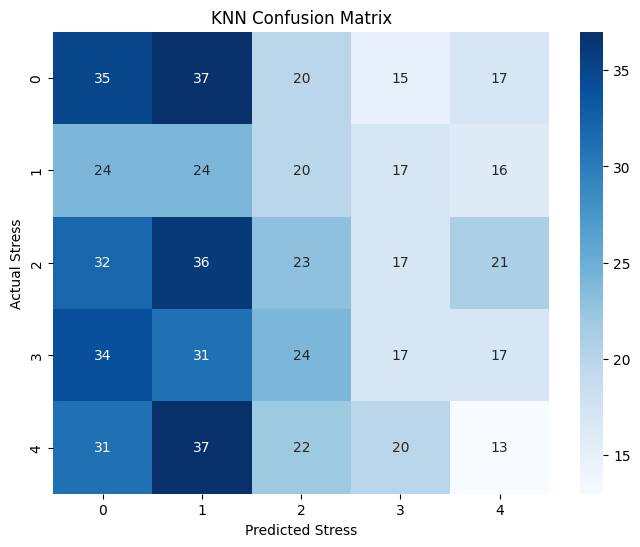

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Load Data
df = pd.read_csv('data/train.csv')

# 2. Features and Target
X = df.drop(columns=['Employee_Id', 'Stress_Level'])
y = df['Stress_Level']

# 3. Preprocessing (KNN needs Scaling to calculate distances correctly)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# 4. Pipeline with KNN
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# 5. Find the "Ideal K" (Hyperparameter Tuning)
# We test different K values to see which one works best for your idea
param_grid = {'classifier__n_neighbors': [3, 5, 7, 11, 15, 21]}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 6. Best Model
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)

# 7. Evaluation
print(f"--- Ideal KNN Evaluation ---")
print(f"Best K Value Found: {grid_search.best_params_['classifier__n_neighbors']}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")

# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Stress')
plt.ylabel('Actual Stress')
plt.show()

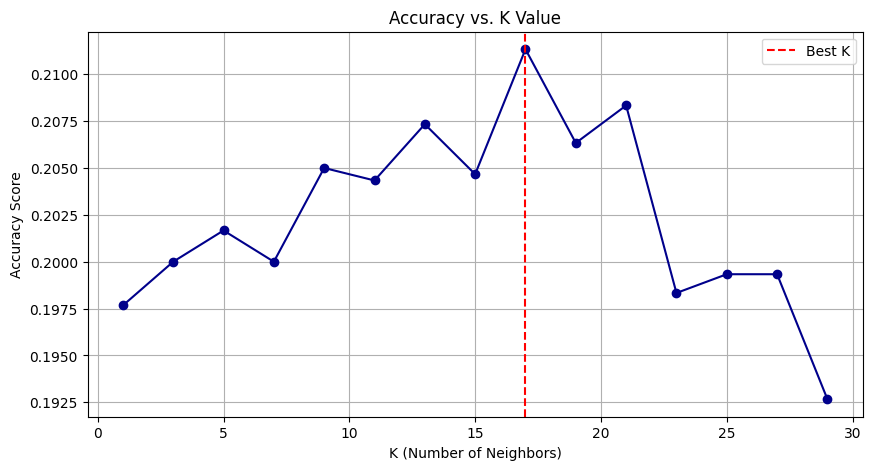

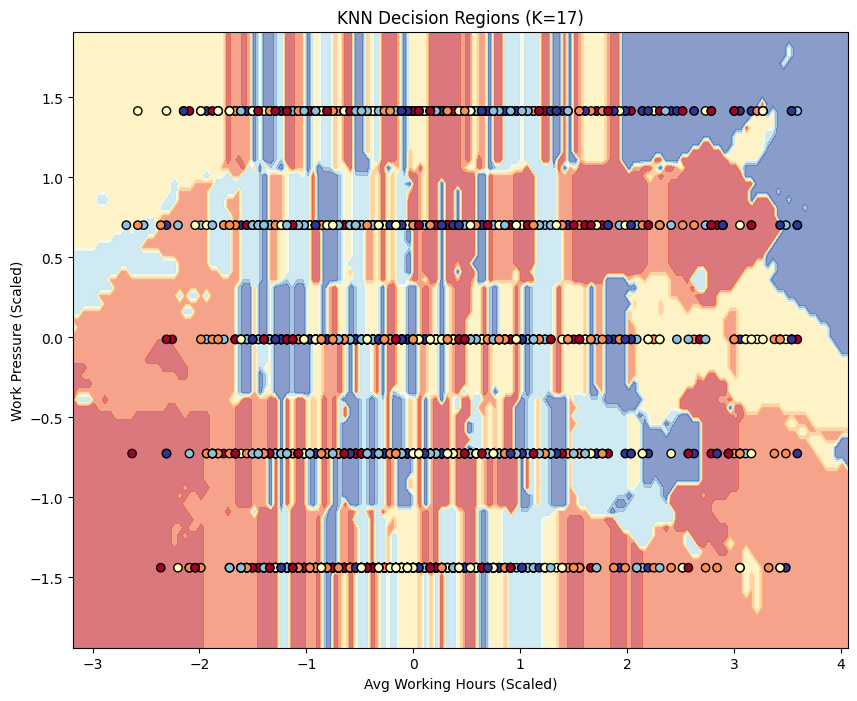

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

X = df[['Avg_Working_Hours_Per_Day', 'Work_Pressure']]
y = df['Stress_Level']

# Scaling is mandatory for KNN to work correctly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Plot 1: Finding the Best K ---
k_range = range(1, 31, 2)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 5-fold cross-validation
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_range, k_scores, marker='o', color='darkblue', linestyle='-')
plt.axvline(x=k_range[np.argmax(k_scores)], color='red', linestyle='--', label='Best K')
plt.title('Accuracy vs. K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 2: Decision Boundaries ---
best_k = k_range[np.argmax(k_scores)]
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_scaled, y)

# Create mesh grid
h = .05
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = knn_final.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.title(f'KNN Decision Regions (K={best_k})')
plt.xlabel('Avg Working Hours (Scaled)')
plt.ylabel('Work Pressure (Scaled)')
plt.show()